#### Wearabel Data Analysis
This is a synthetic data set so the finding may be not real


In [ ]:
# dataset creation
import os
import pandas as pd

root_dir = "customers"

all_dataframes = []

for root, dirs, files in os.walk(root_dir):
    
    if "wearable" in os.path.basename(root).lower():
        
        for file in files:
            if ".csv" in file.lower():
                
                file_path = os.path.join(root, file)
            
                # robust CSV reading
                df = pd.read_csv(
                    file_path,
                    encoding="utf-8",
                    on_bad_lines="skip"
                )
                df["source_file"] = file
                
                all_dataframes.append(df)
                    
merged_df = pd.concat(all_dataframes, ignore_index=True, sort=False)

print(f"Total rows merged: {len(merged_df)}")
print(f"Total files merged: {len(all_dataframes)}")

merged_df.to_csv("merged_wearable_data.csv", index=False)
print("Saved: merged_wearable_data.csv")

Total rows merged: 3600
Total files merged: 5
Saved: merged_wearable_data.csv


In [7]:
df = pd.read_csv('merged_wearable_data.csv')

In [9]:
df.columns

Index(['timestamp', 'customer_id', 'patient_name', 'heart_rate_bpm',
       'spo2_pct', 'steps', 'skin_temp_c', 'hrv_ms', 'respiratory_rate',
       'activity', 'source_file'],
      dtype='str')

In [10]:
df.head()

,timestamp,customer_id,patient_name,heart_rate_bpm,spo2_pct,steps,skin_temp_c,hrv_ms,respiratory_rate,activity,source_file
0,2026-04-11 00:05:29,CUST_amara_patel_03630F04,Amara Patel,94,94.1,47,36.5,52,12,walking,Wearable_CUST_ama_20260511.csv
1,2026-04-11 01:45:29,CUST_amara_patel_03630F04,Amara Patel,98,95.7,229,36.9,71,12,walking,Wearable_CUST_ama_20260511.csv
2,2026-04-11 02:44:29,CUST_amara_patel_03630F04,Amara Patel,88,95.1,110,37.3,41,13,resting,Wearable_CUST_ama_20260511.csv
3,2026-04-11 03:24:29,CUST_amara_patel_03630F04,Amara Patel,78,97.4,309,36.5,22,19,resting,Wearable_CUST_ama_20260511.csv
4,2026-04-11 04:59:29,CUST_amara_patel_03630F04,Amara Patel,83,96.2,321,36.9,75,17,walking,Wearable_CUST_ama_20260511.csv


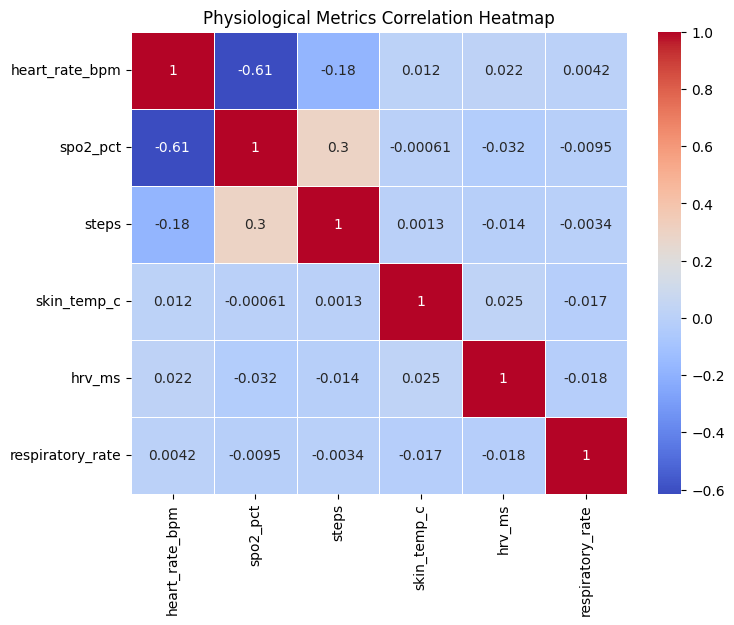

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[[
    "heart_rate_bpm",
    "spo2_pct",
    "steps",
    "skin_temp_c",
    "hrv_ms",
    "respiratory_rate"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Physiological Metrics Correlation Heatmap")
plt.show()

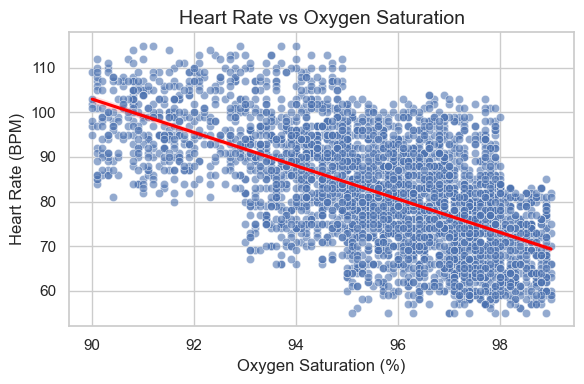

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Style for professional look
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="spo2_pct",
    y="heart_rate_bpm",
    alpha=0.6
)

# Add regression line
sns.regplot(
    data=df,
    x="spo2_pct",
    y="heart_rate_bpm",
    scatter=False,
    color="red"
)

plt.title("Heart Rate vs Oxygen Saturation", fontsize=14)
plt.xlabel("Oxygen Saturation (%)", fontsize=12)
plt.ylabel("Heart Rate (BPM)", fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\Nirasha J\AppData\Local\Temp\ipykernel_36376\28145035.py:17: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Nirasha J\Personal HealthData Platform\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


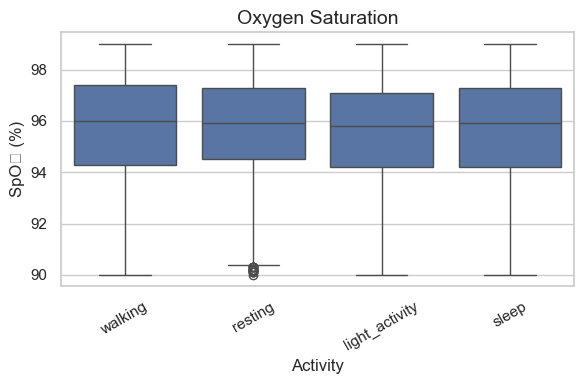

In [23]:

# Clean style
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="activity",
    y="spo2_pct"
)

plt.title("Oxygen Saturation", fontsize=14)
plt.xlabel("Activity", fontsize=12)
plt.ylabel("SpO₂ (%)", fontsize=12)

plt.xticks(rotation=30)  # helps if labels are long
plt.tight_layout()

plt.show()

In [25]:
resting_df = df[df["activity"].str.lower() == "resting"]
Q1 = resting_df["spo2_pct"].quantile(0.25)
Q3 = resting_df["spo2_pct"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = resting_df[
    (resting_df["spo2_pct"] < lower_bound) |
    (resting_df["spo2_pct"] > upper_bound)
]
outliers[[
    "timestamp",
    "customer_id",
    "patient_name",
    "spo2_pct",
    "heart_rate_bpm",
    "hrv_ms"
]].sort_values("timestamp")

,timestamp,customer_id,patient_name,spo2_pct,heart_rate_bpm,hrv_ms
2921,2026-04-12 17:32:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.2,99,34
2940,2026-04-13 12:33:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.0,109,50
3085,2026-04-19 13:59:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.1,91,80
3158,2026-04-22 14:55:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.3,89,27
3231,2026-04-25 15:04:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.3,90,69
3242,2026-04-26 02:05:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.1,108,40
3295,2026-04-28 07:43:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.2,92,46
3311,2026-04-28 23:52:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.1,86,31
3326,2026-04-29 14:31:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.1,97,43
3330,2026-04-29 18:35:29,CUST_mei_lin_66CBFE0F,Mei Lin,90.3,95,57


In [20]:
# Create a rule based risk indicator 
df["risk_flag"] = 0

# Heart rate risk
df.loc[df["heart_rate_bpm"] > 100, "risk_flag"] += 1

# Low oxygen saturation
df.loc[df["spo2_pct"] < 95, "risk_flag"] += 1

# Low HRV (stress indicator)
df.loc[df["hrv_ms"] < 40, "risk_flag"] += 1

# High respiratory rate
df.loc[df["respiratory_rate"] > 18, "risk_flag"] += 1

risk_summary = df.groupby("customer_id").agg(
    total_records=("risk_flag", "count"),
    risk_events=("risk_flag", "sum"),
    avg_heart_rate=("heart_rate_bpm", "mean"),
    avg_spo2=("spo2_pct", "mean"),
    avg_hrv=("hrv_ms", "mean")
)

risk_summary["risk_score"] = risk_summary["risk_events"] / risk_summary["total_records"]

high_risk_customers = risk_summary.sort_values("risk_score", ascending=False)

high_risk_customers.head()

,total_records,risk_events,avg_heart_rate,avg_spo2,avg_hrv,risk_score
customer_id,,,,,,
CUST_mei_lin_66CBFE0F,720,1379,97.234722,92.518750,51.137500,1.915278
CUST_john_whitfield_C4987FD5,720,780,82.798611,94.981667,50.172222,1.083333
CUST_amara_patel_03630F04,720,583,87.845833,96.009028,49.086111,0.809722
CUST_fatima_alsayed_8594AA83,720,423,72.736111,96.501944,47.773611,0.587500
CUST_carlos_rivera_5A81755B,720,390,69.579167,97.989583,50.256944,0.541667
